# Cajal: Programs as Recurrent Neural Networks

The **Cajal** language (Velez-Ginorio, Amin, Kording, Zdancewic) is a typed, higher-order, linear programming language whose programs *compile exactly* to weight matrices of recurrent neural networks.

This notebook demonstrates:
1. Boolean functions compile to binary matrices
2. Natural numbers are encoded as one-hot vectors
3. Iteration compiles to matrix powers (recurrent neurons)
4. The symbolic evaluator and neural compiler give identical outputs

### Boolean encoding in Cajal

- `True  → [1, 0]` (one-hot)
- `False → [0, 1]` (one-hot)
- `NOT x = if x then False else True`  → encoded as a 2×2 swap matrix

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Match the device that cajal's compiler uses internally
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

from cajal.syntax import (
    TmTrue, TmFalse, TmIf, TmFun,
    TmIter, TmVar, TmApp,
    TyBool, TyNat,
    VTrue, VFalse,
)
from cajal.evaluating import evaluate
from cajal.compiling import compile, mat_of_lmap, TypedTensor
from cajal.typing import check

print("Cajal imported successfully")

# Helpers: build NOT, AND, OR using TmIf (Cajal's core boolean eliminator)
def tm_not(x):   return TmIf(x, TmFalse(), TmTrue())
def tm_and(x,y): return TmIf(x, y, TmFalse())
def tm_or(x,y):  return TmIf(x, TmTrue(), y)

Device: mps
Cajal imported successfully


## 1. Boolean Functions Compile to Matrices

In [2]:
programs = {
    "identity  (λx. x)":           TmFun("x", TyBool(), TmVar("x")),
    "NOT       (λx. if x tt ff)":  TmFun("x", TyBool(), tm_not(TmVar("x"))),
    "const-tt  (λx. tt)":          TmFun("x", TyBool(), TmIf(TmVar("x"), TmTrue(), TmTrue())),
    "const-ff  (λx. ff)":          TmFun("x", TyBool(), TmIf(TmVar("x"), TmFalse(), TmFalse())),
}

print("Boolean functions → matrices:")
for name, tm in programs.items():
    check(tm, {})
    c_tm = compile(tm)
    lmap = c_tm({})
    matrix = mat_of_lmap(lmap)
    print(f"  {name}")
    print(f"    matrix: {matrix.data.tolist()}")

Boolean functions → matrices:
  identity  (λx. x)
    matrix: [[1.0, 0.0], [0.0, 1.0]]
  NOT       (λx. if x tt ff)
    matrix: [[0.0, 1.0], [1.0, 0.0]]
  const-tt  (λx. tt)
    matrix: [[1.0, 1.0], [0.0, 0.0]]
  const-ff  (λx. ff)
    matrix: [[0.0, 0.0], [1.0, 1.0]]


In [3]:
# Verify: symbolic evaluator and neural compiler agree on all inputs
N_STEPS = 10

true_tt  = TypedTensor(torch.tensor([1.0, 0.0], device=device), TyBool())
false_tt = TypedTensor(torch.tensor([0.0, 1.0], device=device), TyBool())

def tt_to_str(tt):
    return "True" if tt.data[0] > 0.5 else "False"

def val_to_str(v):
    return "True" if isinstance(v, VTrue) else "False"

# Test NOT on both inputs
not_prog = tm_not(TmVar("x"))
not_compiled = compile(not_prog)

print("NOT verification (symbolic vs neural):")
print(f"  {'Input':8s}  {'Symbolic':10s}  {'Neural':10s}  {'Match':5s}")
for (tt_val, label), v_val in [((true_tt, "True"), VTrue()), ((false_tt, "False"), VFalse())]:
    sym_result  = evaluate(not_prog, {"x": v_val})
    neur_result = not_compiled({"x": tt_val})
    sym_str  = val_to_str(sym_result)
    neur_str = tt_to_str(neur_result)
    match = sym_str == neur_str
    print(f"  {label:8s}  {sym_str:10s}  {neur_str:10s}  {'✓' if match else '✗':5s}")

NOT verification (symbolic vs neural):
  Input     Symbolic    Neural      Match
  True      False       False       ✓    
  False     True        True        ✓    


## 2. Iteration as a Recurrent Neuron

The key Cajal construct for scientific simulation is **iteration**:

```
iter{e₁ | y ↪ e₂}(e₃)
```

- `e₁`: initial state
- `y ↪ e₂`: step function
- `e₃`: number of steps (natural number, one-hot encoded)

When compiled, this becomes a **recurrent neural network**: the matrix is applied `n` times.

Here we iterate NOT 0–9 times. NOT applied even times → True, odd times → False.

In [4]:
program = TmIter(
    TmVar("x0"),
    "x",
    tm_not(TmVar("x")),   # step: NOT
    TmVar("n"),
)
compiled = compile(program)

x0 = TypedTensor(torch.tensor([1.0, 0.0], device=device), TyBool())  # True

print("iter{True | x ↪ NOT(x)}(n):")
print(f"  {'n':>3s}  {'Result':>8s}  {'Expected':>8s}  {'Match':>5s}")
for i in range(N_STEPS):
    n_onehot = torch.zeros(N_STEPS, device=device)
    n_onehot[i] = 1.0
    n_val = TypedTensor(n_onehot, TyNat())
    result = compiled({"x0": x0, "n": n_val})
    got      = tt_to_str(result)
    expected = "True" if i % 2 == 0 else "False"
    print(f"  {i:3d}  {got:>8s}  {expected:>8s}  {'✓' if got == expected else '✗':>5s}")

iter{True | x ↪ NOT(x)}(n):
    n    Result  Expected  Match


    0      True      True      ✓
    1     False     False      ✓
    2      True      True      ✓
    3     False     False      ✓
    4      True      True      ✓
    5     False     False      ✓
    6      True      True      ✓
    7     False     False      ✓


    8      True      True      ✓
    9     False     False      ✓


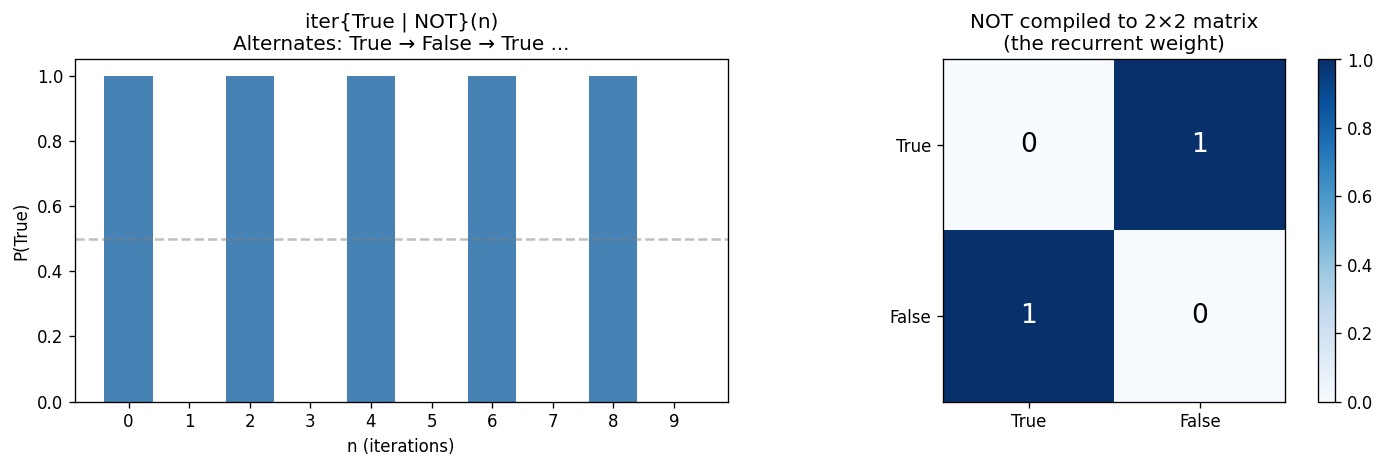

NOT matrix:
  [[0, 1],   # True  → False
   [1, 0]]   # False → True


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results = []
for i in range(N_STEPS):
    n_onehot = torch.zeros(N_STEPS, device=device)
    n_onehot[i] = 1.0
    result = compiled({"x0": x0, "n": TypedTensor(n_onehot, TyNat())})
    results.append(result.data[0].item())

ax = axes[0]
colors = ['steelblue' if r > 0.5 else 'coral' for r in results]
ax.bar(range(N_STEPS), results, color=colors)
ax.set_xlabel('n (iterations)')
ax.set_ylabel('P(True)')
ax.set_title('iter{True | NOT}(n)\nAlternates: True → False → True ...')
ax.set_xticks(range(N_STEPS))
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

# Show the matrix for NOT (mat_of_lmap returns CPU tensor via .numpy())
not_fn = TmFun("x", TyBool(), tm_not(TmVar("x")))
check(not_fn, {})
lmap = compile(not_fn)({})
mat = mat_of_lmap(lmap).data.cpu().numpy()

ax2 = axes[1]
im = ax2.imshow(mat, cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(['True', 'False'])
ax2.set_yticklabels(['True', 'False'])
ax2.set_title('NOT compiled to 2×2 matrix\n(the recurrent weight)')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{mat[i,j]:.0f}', ha='center', va='center',
                 color='white' if mat[i,j] > 0.5 else 'black', fontsize=16)
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig('cajal_iteration.png', dpi=120, bbox_inches='tight')
plt.show()

print("NOT matrix:")
print(f"  [[{mat[0,0]:.0f}, {mat[0,1]:.0f}],   # True  → False")
print(f"   [{mat[1,0]:.0f}, {mat[1,1]:.0f}]]   # False → True")

## Key Takeaway

Cajal programs **are** neural networks — not approximations. The compiler produces exact weight matrices, and the symbolic evaluator and neural compiler produce identical results.

The **NOT matrix** `[[0,1],[1,0]]` is a 2×2 permutation matrix. When applied twice (`NOT² = identity`), we get `[[1,0],[0,1]]` — which is why iterating NOT alternates True/False.

In the next notebooks, we replace the fixed `NOT` with a **learnable PyTorch module** — enabling gradient-based learning of the step function from data, while preserving the structural correctness of the Cajal program.